# <center>Team 7 — Code Avengers </center>
## Labs + Prescription Medication Analysis
### Descriptive Analysis and Prescriptive Analysis

- **Primary dataset 1: Labs** — 2,008 patient-level rows and a wide range of physiologic/laboratory variables.
- **Primary dataset 2: Patient Prescriptions** — medication exposure records with multiple drugs per patient.
- **Supporting dataset: Demography** — used only for meaningful segmentation such as **age category, gender, BMI, weight and height**.

> **Important:** Prescriptive analysis here means **what the analytics team should review or investigate next**.  
> It does **not** prescribe medications or provide clinical treatment recommendations.

# Import, File Loading and Merging

In [1]:
# %pip install pandas numpy plotly scipy nbformat

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import spearmanr, mannwhitneyu


In [2]:
# Define the main project folder
project_folder = Path(
    r"C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\__Final_Cleaned Dataset"
)

# Define CSV filenames
FILES = {
    "labs": "Team7_CodeAvengers_Category1_DataCleaning_labs.csv",
    "prescriptions": "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv",
    "demography": "Team7_CodeAvengers_Category1_DataCleaning_demography.csv",
}

# Read the cleaned datasets
labs = pd.read_csv(project_folder / FILES["labs"])
prescriptions = pd.read_csv(project_folder / FILES["prescriptions"])
demography = pd.read_csv(project_folder / FILES["demography"])

# Verify successful loading
print("Labs:", labs.shape)
print("Prescriptions:", prescriptions.shape)
print("Demography:", demography.shape)

Labs: (2008, 107)
Prescriptions: (15362, 2)
Demography: (2008, 7)


In [3]:
# Validate patient-level uniqueness before merging.
for name, df in {"labs": labs, "demography": demography}.items():
    print("\t")
    print(
        f"{name:12s} rows={len(df):,} | "
        f"unique patients={df['inpatient_number'].nunique():,} | "
        f"duplicate patient IDs={df['inpatient_number'].duplicated().sum():,}"
    )
print("\t")
print(
    f"prescriptions rows={len(prescriptions):,} | "
    f"unique patients={prescriptions['inpatient_number'].nunique():,} | "
    f"unique drug names={prescriptions['drug_name'].nunique():,}"
)

# Clean drug-name whitespace only; do not change clinical content.
rx = prescriptions.copy()
rx["drug_name"] = rx["drug_name"].astype(str).str.strip()

# Aggregate prescriptions BEFORE patient-level merge to avoid multiplying lab rows.
rx_summary = (
    rx.groupby("inpatient_number")
      .agg(
          prescription_rows=("drug_name", "size"),
          unique_medication_count=("drug_name", "nunique")
      )
      .reset_index()
)

patient = (
    labs
    .merge(demography, on="inpatient_number", how="left", validate="one_to_one")
    .merge(rx_summary, on="inpatient_number", how="left", validate="one_to_one")
)

patient[["prescription_rows", "unique_medication_count"]] = (
    patient[["prescription_rows", "unique_medication_count"]].fillna(0)
)

AGE_ORDER = ["21-29", "29-39", "39-49", "49-59", "59-69", "69-79", "79-89", "89-110"]
AGE_MIDPOINT = {
    "21-29": 25, "29-39": 34, "39-49": 44, "49-59": 54,
    "59-69": 64, "69-79": 74, "79-89": 84, "89-110": 99.5
}

patient["agecat"] = pd.Categorical(patient["agecat"], categories=AGE_ORDER, ordered=True)
patient["age_midpoint"] = patient["agecat"].astype(str).map(AGE_MIDPOINT)

print("\n Final patient-level analytical dataset:", patient.shape)
print("\n Unique patients:", patient["inpatient_number"].nunique())

	
labs         rows=2,008 | unique patients=2,008 | duplicate patient IDs=0
	
demography   rows=2,008 | unique patients=2,008 | duplicate patient IDs=0
	
prescriptions rows=15,362 | unique patients=2,007 | unique drug names=25

 Final patient-level analytical dataset: (2008, 116)

 Unique patients: 2008


In [4]:
# Helper functions reused throughout the notebook.

def p_text(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "< 0.001"
    return f"= {p:.3f}"

def safe_spearman(df, x, y):
    tmp = df[[x, y]].dropna()
    if len(tmp) < 3:
        return np.nan, np.nan, len(tmp)
    rho, p = spearmanr(tmp[x], tmp[y])
    return rho, p, len(tmp)

def med_usage_by_group(group_col, drugs):
    unique_rx = (
        rx.drop_duplicates(["inpatient_number", "drug_name"])
          .merge(patient[["inpatient_number", group_col]], on="inpatient_number", how="left")
    )
    numerator = (
        unique_rx[unique_rx["drug_name"].isin(drugs)]
        .groupby([group_col, "drug_name"], observed=True)["inpatient_number"]
        .nunique()
        .unstack(fill_value=0)
    )
    denominator = patient.groupby(group_col, observed=True)["inpatient_number"].nunique()
    return numerator.div(denominator, axis=0) * 100

def standardized_mean_difference(df, group_col, value_col):
    a = df.loc[df[group_col], value_col].dropna()
    b = df.loc[~df[group_col], value_col].dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt(
        ((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1))
        / (len(a)+len(b)-2)
    )
    return (a.mean()-b.mean())/pooled if pooled else np.nan

# <center>DESCRIPTIVE ANALYSIS </center> 

The objective is to **describe and explain the observed patterns** in the cleaned Labs and Prescription datasets.

Demography is used only when it helps answer a meaningful subgroup question.

### DA5: How do average eGFR levels differ across age groups and genders, and what demographic patterns emerge in renal function? 
**Analysis type:** Descriptive — Lab × age

**Reasoning**  

Comparing eGFR levels across age groups and genders helps us understand how kidney function measurements differ among patients. A line chart makes it easier to identify changes in average eGFR levels across age categories and compare patterns between males and females.


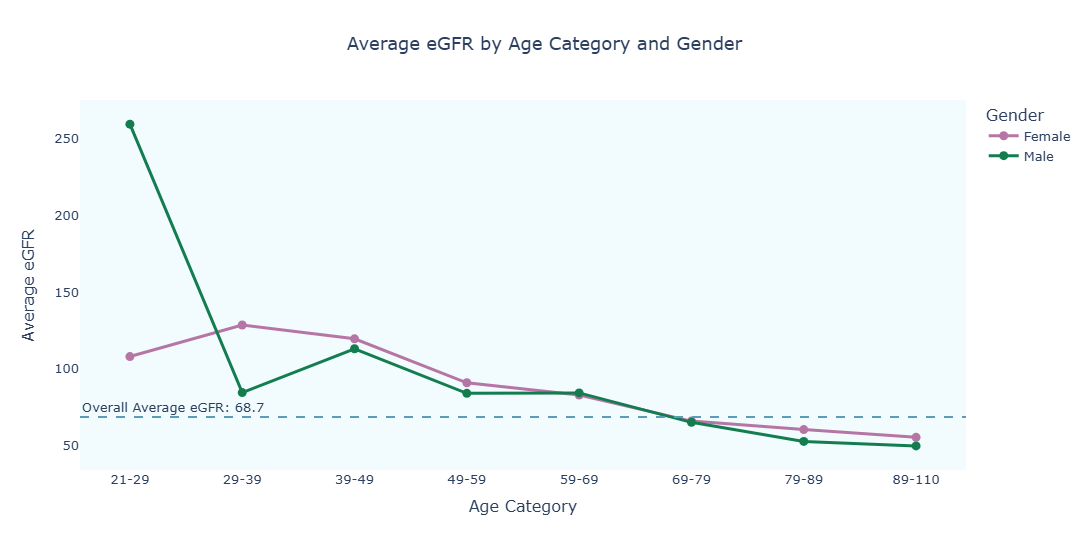

,Age Category,Gender,Average eGFR,Records
0,21-29,Female,108.06,3
1,21-29,Male,259.51,1
2,29-39,Female,128.59,5
3,29-39,Male,84.58,7
4,39-49,Female,119.61,17
5,39-49,Male,113.15,37
6,49-59,Female,90.96,49
7,49-59,Male,84.11,55
8,59-69,Female,82.98,182
9,59-69,Male,84.37,172


In [5]:
# Prepare data
tmp = patient[
    ["agecat", "gender", "glomerular_filtration_rate"]
].dropna()

# Calculate average eGFR by age category and gender
egfr_by_group = (
    tmp.groupby(["agecat", "gender"], observed=True)["glomerular_filtration_rate"]
       .agg(["mean", "count"])
       .reset_index()
)

# Create line chart
fig = px.line(
    egfr_by_group,
    x="agecat",
    y="mean",
    color="gender",
    markers=True,
    title="Average eGFR by Age Category and Gender",
    labels={
        "agecat": "Age Category",
        "mean": "Average eGFR",
        "gender": "Gender"
    },
    color_discrete_sequence=["#B576A5", "#147D50"],
    hover_data=["count"]
)

# Customize lines and markers
fig.update_traces(
    line=dict(width=3),
    marker=dict(size=9)
)

# Add overall average reference line
overall_avg = tmp["glomerular_filtration_rate"].mean()

fig.add_hline(
    y=overall_avg,
    line_dash="dash",
    line_color="#5B9DB8",
    annotation_text=f"Overall Average eGFR: {overall_avg:.1f}",
    annotation_position="top left"
)

# Customize chart appearance
fig.update_layout(
    height=550,
    plot_bgcolor="#F2FBFD",
    paper_bgcolor="white",
    title_x=0.5,
    xaxis_title="Age Category",
    yaxis_title="Average eGFR",
    legend_title="Gender",
    font=dict(size=13),
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

fig.show()

# Display summary table
display(
    egfr_by_group
    .rename(columns={
        "agecat": "Age Category",
        "gender": "Gender",
        "mean": "Average eGFR",
        "count": "Records"
    })
    .round(2)
)

**Actual Insight**  
Average eGFR levels generally decrease as age increases, suggesting that kidney function tends to be lower in older patients. Males and females show a similar pattern after age 39, with eGFR levels falling below the overall average in the older age groups. The unusually high value for males aged 21–29 may be due to a small number of records and should be checked before drawing conclusions.

## DA8: How does the utilization of the most commonly prescribed medications differ across age groups, and what age-related medication-use patterns can be identified? 

## Analysis type: Descriptive — Prescription × age heat map

* Reasoning

A heat map can compare several medications and age categories simultaneously. Percent prevalence is used instead of raw counts so age groups with different sizes can be compared fairly.

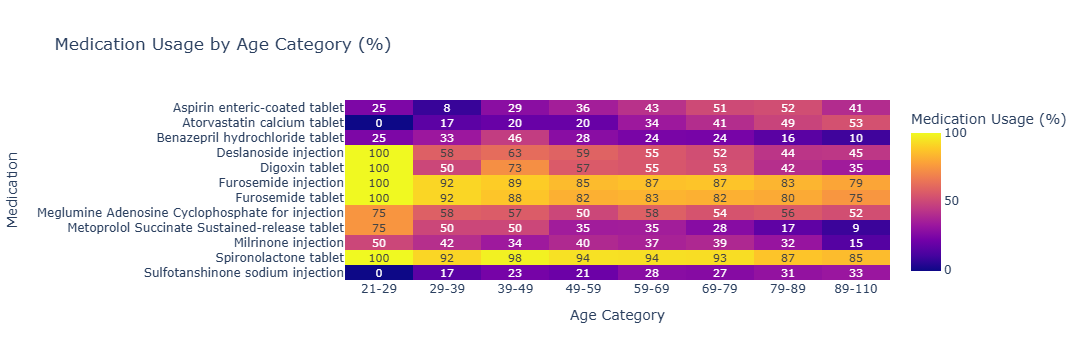

drug_name,Aspirin enteric-coated tablet,Atorvastatin calcium tablet,Benazepril hydrochloride tablet,Deslanoside injection,Digoxin tablet,Furosemide injection,Furosemide tablet,Meglumine Adenosine Cyclophosphate for injection,Metoprolol Succinate Sustained-release tablet,Milrinone injection,Spironolactone tablet,Sulfotanshinone sodium injection
agecat,,,,,,,,,,,,
21-29,25.0,0.0,25.0,100.0,100.0,100.0,100.0,75.0,75.0,50.0,100.0,0.0
29-39,8.3,16.7,33.3,58.3,50.0,91.7,91.7,58.3,50.0,41.7,91.7,16.7
39-49,28.6,19.6,46.4,62.5,73.2,89.3,87.5,57.1,50.0,33.9,98.2,23.2
49-59,35.8,19.8,28.3,59.4,56.6,84.9,82.1,50.0,34.9,39.6,94.3,20.8
59-69,42.7,33.7,24.2,55.4,55.2,86.7,83.2,58.4,35.3,37.2,93.8,28.3
69-79,51.2,41.1,23.6,52.3,53.1,87.4,82.2,54.1,27.7,39.3,93.3,27.4
79-89,52.3,48.9,16.3,43.8,41.6,83.4,80.5,56.3,17.3,31.9,87.5,31.0
89-110,40.6,53.5,9.9,44.6,34.7,79.2,75.2,52.5,8.9,14.9,85.1,32.7


In [6]:
# ---------------------------------------------------------
# DA8: Medication Utilization by Age Category
# ---------------------------------------------------------

# Keep patient age-category information
patient_data = (
    patient[["inpatient_number", "agecat"]]
    .dropna()
    .drop_duplicates()
)

# Keep prescription information
rx_data = (
    rx[["inpatient_number", "drug_name"]]
    .dropna()
    .drop_duplicates()
)

# Merge age category with medication information
med_data = patient_data.merge(
    rx_data,
    on="inpatient_number",
    how="inner"
)

# ---------------------------------------------------------
# Identify the 12 most commonly used medications
# ---------------------------------------------------------

drug_prev = (
    med_data.groupby("drug_name")["inpatient_number"]
    .nunique()
    .sort_values(ascending=False)
)

top_drugs = drug_prev.head(12).index.tolist()


# ---------------------------------------------------------
# Count number of patients in each age category
# ---------------------------------------------------------

age_counts = (
    patient_data.groupby("agecat")["inpatient_number"]
    .nunique()
)


# ---------------------------------------------------------
# Calculate medication use by age category
# ---------------------------------------------------------

med_counts = (
    med_data[med_data["drug_name"].isin(top_drugs)]
    .groupby(["agecat", "drug_name"])["inpatient_number"]
    .nunique()
    .unstack(fill_value=0)
)


# Convert counts to prevalence percentage within each age group
age_med = (
    med_counts
    .div(age_counts, axis=0)
    .mul(100)
)


# Keep your predefined clinical age-category order
age_med = age_med.reindex(AGE_ORDER)


# ---------------------------------------------------------
# Heatmap
# ---------------------------------------------------------

fig = px.imshow(
    age_med.T,
    aspect="auto",
    text_auto=".0f",
    title="Medication Usage by Age Category (%)",
    labels={
        "x": "Age Category",
        "y": "Medication",
        "color": "Medication Usage (%)"
    }
)

fig.show()


# Display calculated prevalence values
display(age_med.round(1))

## Actual Insight: 
Medication utilization differs across age groups, with certain commonly prescribed drugs showing greater usage in specific age categories. These patterns may reflect age-related differences in chronic disease burden and treatment requirements and can help identify patient groups where medication use may require closer clinical review.